In [2]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *

from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

import warnings
warnings.filterwarnings("ignore")

In [3]:
# 1. Define your luminosity distance with a unit
luminosity_dist = 1e5 * u.Mpc

# 2. Find the redshift corresponding to this luminosity distance
redshift = z_at_value(Planck18.luminosity_distance, luminosity_dist)

print(f"Redshift: {redshift:.4f}")

Redshift: 9.5000 redshift


In [18]:
from lisagwresponse import ResponseFromStrain
from pycbc.waveform import get_fd_waveform, get_td_waveform
from scipy.interpolate import interp1d

class BinaryInspiralGW(ResponseFromStrain):
    """Represents a GW resulting from a binary merger.
    """
    def __init__(self, m1, m2, d, t_inj, spin1=0.0, spin2=0.0, iota=0.0,
                 domain='freq', **kwargs,) -> None:
        super().__init__(**kwargs)
        self.t_inj = float(t_inj)
        self.m1 = float(m1)
        self.m2 = float(m2)
        self.d = float(d)
        self.spin1 = float(spin1)
        self.spin2 = float(spin2)
        self.iota = float(iota)
        self.domain = domain
        self.f_lower = self.compute_flower()

        if self.domain == 'time':
            hp_td, hc_td = get_td_waveform(approximant="IMRPhenomXHM",
                mass1=self.m1, mass2=self.m2, delta_t=1e-3/self.f_lower, f_lower=self.f_lower, 
                inclination=self.iota, distance=self.d, spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_td
            self.hc = hc_td
            
        elif self.domain == 'freq':
            hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM",
                        mass1=self.m1, mass2=self.m2, delta_f=self.f_lower/1e3,
                        f_lower=self.f_lower, distance=self.d, inclination=self.iota,
                        spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_fd.to_timeseries()
            self.hc = hc_fd.to_timeseries()
        self.amp_hp = max(self.hp)
        self.amp_hc = max(self.hc)
        self.duration = self.compute_duration()

    def compute_flower(self) -> float:
        c = 3e8
        G = 6.67e-11
        M = (self.m1 + self.m2)*2e30
        r = 6
        return (c**3)/(((6*r)**1.5)*np.pi*G*M)

    def compute_duration(self) -> float:
        """compute an approximate duration for the gw"""
        h = np.sqrt(self.hp**2 + self.hc**2)
        threshold = max(h)/30
        
        mask = h >= threshold
        duration = np.sum(mask) * 0.25
        
        return duration

    def compute_hplus(self, t) -> np.ndarray:
        return self.compute_signal(self.hp, self.amp_hp, t)

    def compute_hcross(self, t) -> np.ndarray:
        return self.compute_signal(self.hc, self.amp_hc, t)

    def compute_signal(self, h, amp, t):
        h.start_time = 0
        peak_time = h.sample_times[np.where(np.array(h) == amp)][0]
        delta_t = self.t_inj - t[0] - 405
        h = h.cyclic_time_shift(-(peak_time - delta_t))
        h.start_time = 0
        
        mask1 = h.sample_times < delta_t + 80000
        sigslice = h[mask1]
        tslice = h.sample_times[mask1]
        tslice = tslice + t[0]
        f = interp1d(tslice, sigslice, kind='cubic',
                         bounds_error=False, fill_value=0)
        return f(t)

In [19]:
#from helpers.gw_shapes import *

gw = BinaryInspiralGW(m1 = 1e8, m2=1e8, d=5e4, iota=0, spin1=0, spin2=0, t_inj=24*3600,
                      domain='freq', gw_beta=0, gw_lambda=0, orbits=orbits_path)

You are using an orbit file in a version that might not be fully supported


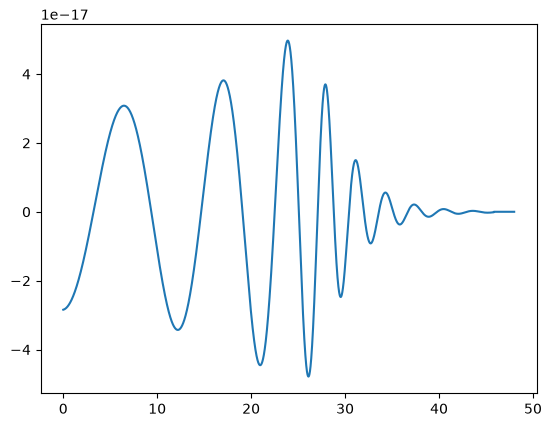

In [20]:
t = np.arange(0, 48*3600, 0.25)
y = gw.compute_hcross(t)

plt.plot(t/3600, y)
plt.show()

In [69]:
from helpers.simulation import *
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']
    
pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
         'keep_noises': ['test-mass', 'oms']}

z = 5
dL = Planck18.luminosity_distance(z).value
m1, m2 = 1e6, 1e6

gws = [{'type': 'BinaryInspiralGW', 'm1': m1*(1+z), 'm2': m2*(1+z),
         'd': dL, 'iota':0, 'spin1': 0, 'spin2': 0, 't_inj': 6*3600, 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]

glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': 4*3600,
              'beta': 20, 'level':2*5e-13*20,
                'inj_point':'tm_12'}]

run_simulation(
            gws, glitches, pipe,
            gw_path, glitch_path, orbits_path,
            simulation_path,
            disable_noise=pipe['keep_noises']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [72]:
from helpers.qtransform import *

tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

event = {'t_inj':5*3600}
res = 256

QT = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_arr, f_arr, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-4, 1e-2), trange=(-3, 3), Q=6)
    QT[:, :, ['A', 'E', 'T'].index(channel)] = data

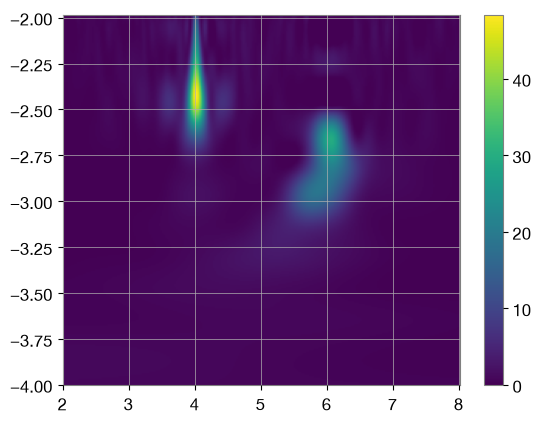

In [73]:
plt.imshow(QT[:, :, 0], extent=[t_arr[0]/3600, t_arr[-1]/3600, np.log10(f_arr[0]), np.log10(f_arr[-1])], aspect='auto', origin='lower')
plt.colorbar()
#plt.clim(0, 5)
plt.show()

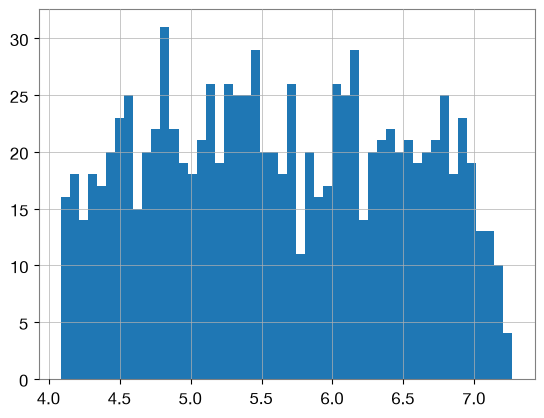

In [49]:
z_arr = np.random.uniform(0.5, 9, size=1000)
d_arr = Planck18.luminosity_distance(z_arr).value

Mc_array = 10**np.random.uniform(4, 7, size=1000)
q_array = np.random.uniform(1, 5, size=1000)

m1_arr = Mc_array * ((1 + q_array)**(1/5) / q_array**(3/5)) * (1+z)
m2_arr = m1_arr * q_array

plt.hist(np.log10(m1_arr), bins=50)
plt.show()